## 如何处理一个序列模型：

![Screenshot 2025-11-19 at 15.35.03.png](img/序列模型1.png)

也就是说，方案一只关注当前时刻前 $\tau$  个信息，而非一个完整的时间序列，这样的方式可以大大简化模型

![序列模型2.png](img/序列模型2.png)

也就是说，需要训练两个模型：
1. 模型一：输入 $h, x$ 预测 $h^\prime$
2. 模型二：输入 $x, h^\prime$ 预测 $x^\prime$

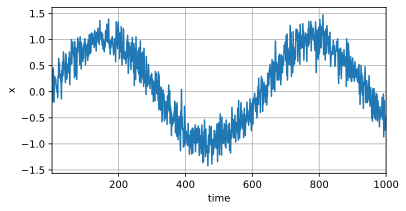

In [8]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

T = 1000
time = torch.arange(1, T + 1, dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0, 0.2 , (T,))
d2l.plot(time, [x], 'time', 'x', xlim=[1, 1000], figsize=(6, 3))

In [18]:
# markov plan
tau = 4
features = torch.zeros((T - tau, tau)) # (996, 4) ---- num of samples: 996
for i in range(tau):
    features[:, i] = x[i: T - tau + i] 
labels = x[tau:].reshape((-1, 1))

batch_size, n_train = 16, 600
train_iter = d2l.load_array((features[:n_train], labels[:n_train]), batch_size, is_train=True)

In [25]:
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

def get_net():
    net = nn.Sequential(nn.Linear(4, 10), nn.ReLU(), nn.Linear(10, 1))
    net.apply(init_weights)
    return net

loss = nn.MSELoss()

In [36]:
def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr)
    for epoch in range(epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            trainer.step()

        print(f'epoch {epoch + 1}, loss: {d2l.evaluate_loss(net, train_iter, loss)}')

net = get_net() 
train(net, train_iter, loss, 10, 0.01) # set 0, without train

epoch 1, loss: 0.07217433847683041
epoch 2, loss: 0.0588457331453499
epoch 3, loss: 0.054286749102175236
epoch 4, loss: 0.05364119746771298
epoch 5, loss: 0.056124804394417686
epoch 6, loss: 0.05068263872281501
epoch 7, loss: 0.0510834068746159
epoch 8, loss: 0.05054114455063092
epoch 9, loss: 0.05000987683275813
epoch 10, loss: 0.051093743721905505


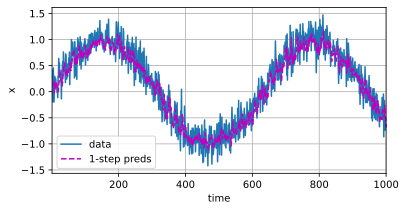

In [37]:
onestep_preds = net(features)
d2l.plot(
    [time, time[tau:]],
    [x.detach().numpy(), onestep_preds.detach().numpy()], 'time', 'x',
    legend=['data', '1-step preds'], xlim=[1, 1000], figsize=(6, 3)
)

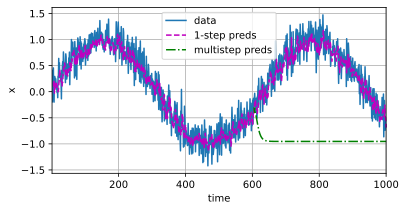

In [38]:
multistep_preds = torch.zeros(T)
multistep_preds[: n_train + tau] = x[: n_train + tau]
for i in range(n_train + tau, T):
    multistep_preds[i] = net(
        multistep_preds[i - tau:i].reshape((1, -1)))

d2l.plot([time, time[tau:], time[n_train + tau:]],
         [x.detach().numpy(), onestep_preds.detach().numpy(),
          multistep_preds[n_train + tau:].detach().numpy()], 'time',
         'x', legend=['data', '1-step preds', 'multistep preds'],
         xlim=[1, 1000], figsize=(6, 3))

问题原因：误差叠加

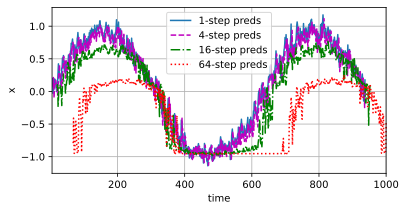

In [41]:
max_steps = 64

features = torch.zeros((T - tau - max_steps + 1, tau + max_steps))
# 列i（i<tau）是来自x的观测，其时间步从（i）到（i+T-tau-max_steps+1）
for i in range(tau):
    features[:, i] = x[i: i + T - tau - max_steps + 1]

# 列i（i>=tau）是来自（i-tau+1）步的预测，其时间步从（i）到（i+T-tau-max_steps+1）
for i in range(tau, tau + max_steps):
    features[:, i] = net(features[:, i - tau:i]).reshape(-1)

steps = (1, 4, 16, 64)
d2l.plot([time[tau + i - 1: T - max_steps + i] for i in steps],
         [features[:, (tau + i - 1)].detach().numpy() for i in steps], 'time', 'x',
         legend=[f'{i}-step preds' for i in steps], xlim=[5, 1000],
         figsize=(6, 3))